In [1]:
import subprocess
subprocess.run(["pip", "install", "--user", "pandas", "matplotlib", "seaborn", "pandasql"], check=True)

CompletedProcess(args=['pip', 'install', '--user', 'pandas', 'matplotlib', 'seaborn', 'pandasql'], returncode=0)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pandasql import sqldf

# Load the dataset
df = pd.read_csv('netflix_titles.csv')

# First look
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (8807, 12)

Missing values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

First 5 rows:


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
# Fill missing values where we want to keep the rows
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')

# Drop rows where rating, duration, and date_added are missing
df_clean = df.dropna(subset=['rating', 'duration', 'date_added'])

# Convert date_added to datetime
df_clean = df_clean.copy()
df_clean['date_added'] = pd.to_datetime(df_clean['date_added'].str.strip())
df_clean['year_added'] = df_clean['date_added'].dt.year
df_clean['month_added'] = df_clean['date_added'].dt.month

# Confirm cleaning
print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)
print("Rows removed:", df.shape[0] - df_clean.shape[0])

Original shape: (8807, 12)
Cleaned shape: (8790, 14)
Rows removed: 17


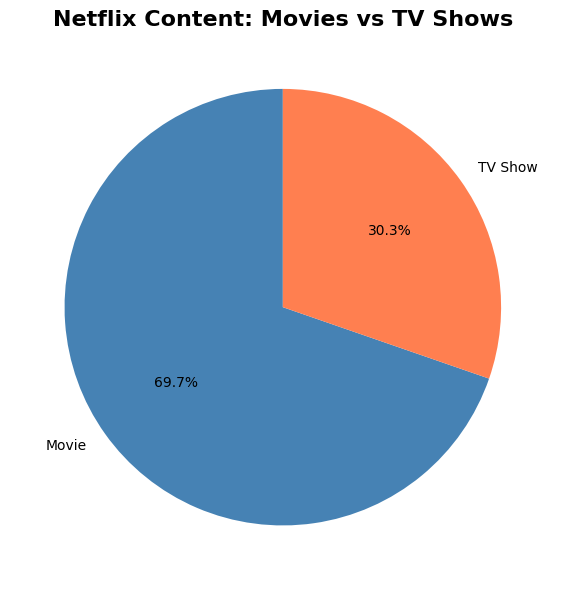

      type  Total_Titles  Percentage
0    Movie          6126        69.7
1  TV Show          2664        30.3


In [4]:
# ---- ANALYSIS 1: Movies vs TV Shows ----
content_type = df_clean['type'].value_counts()

plt.figure(figsize=(8, 6))
plt.pie(content_type.values, labels=content_type.index, autopct='%1.1f%%', 
        colors=['steelblue', 'coral'], startangle=90)
plt.title('Netflix Content: Movies vs TV Shows', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('chart1_content_type.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT type,
       COUNT(*) AS Total_Titles,
       ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM df_clean), 1) AS Percentage
FROM df_clean
GROUP BY type
ORDER BY Total_Titles DESC
"""
result = sqldf(query, locals())
print(result)

C:\Users\asus\AppData\Local\Temp\ipykernel_25516\2339324733.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=country_counts.values, y=country_counts.index, palette='Reds_r')


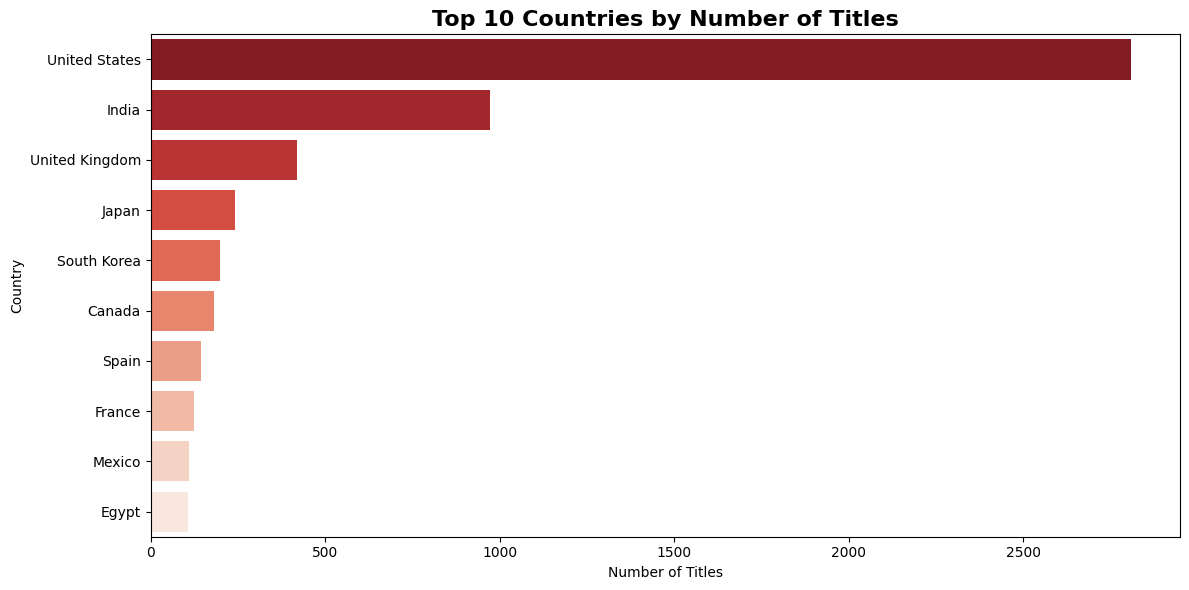

          country  Total_Titles
0   United States          2809
1           India           972
2  United Kingdom           418
3           Japan           243
4     South Korea           199
5          Canada           181
6           Spain           145
7          France           124
8          Mexico           110
9           Egypt           106


In [5]:
# ---- ANALYSIS 2: Top 10 Countries by Content ----
country_counts = df_clean[df_clean['country'] != 'Unknown'].groupby('country')['show_id'].count().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=country_counts.values, y=country_counts.index, palette='Reds_r')
plt.title('Top 10 Countries by Number of Titles', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('chart2_content_by_country.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT country,
       COUNT(*) AS Total_Titles
FROM df_clean
WHERE country != 'Unknown'
GROUP BY country
ORDER BY Total_Titles DESC
LIMIT 10
"""
result = sqldf(query, locals())
print(result)

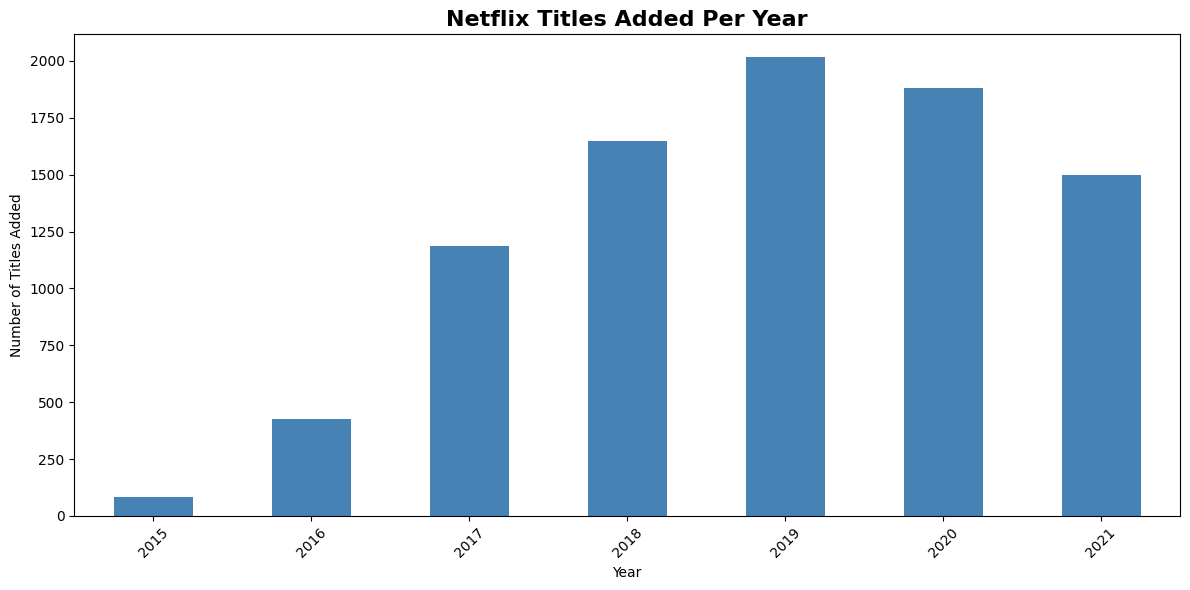

   year_added  Total_Titles
0        2015            82
1        2016           426
2        2017          1185
3        2018          1648
4        2019          2016
5        2020          1879
6        2021          1498


In [6]:
# ---- ANALYSIS 3: Content added per year ----
yearly_content = df_clean[df_clean['year_added'] >= 2015].groupby('year_added')['show_id'].count()

plt.figure(figsize=(12, 6))
yearly_content.plot(kind='bar', color='steelblue')
plt.title('Netflix Titles Added Per Year', fontsize=16, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart3_content_per_year.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT year_added,
       COUNT(*) AS Total_Titles
FROM df_clean
WHERE year_added >= 2015
GROUP BY year_added
ORDER BY year_added ASC
"""
result = sqldf(query, locals())
print(result)

C:\Users\asus\AppData\Local\Temp\ipykernel_25516\3084550210.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Purples_r')


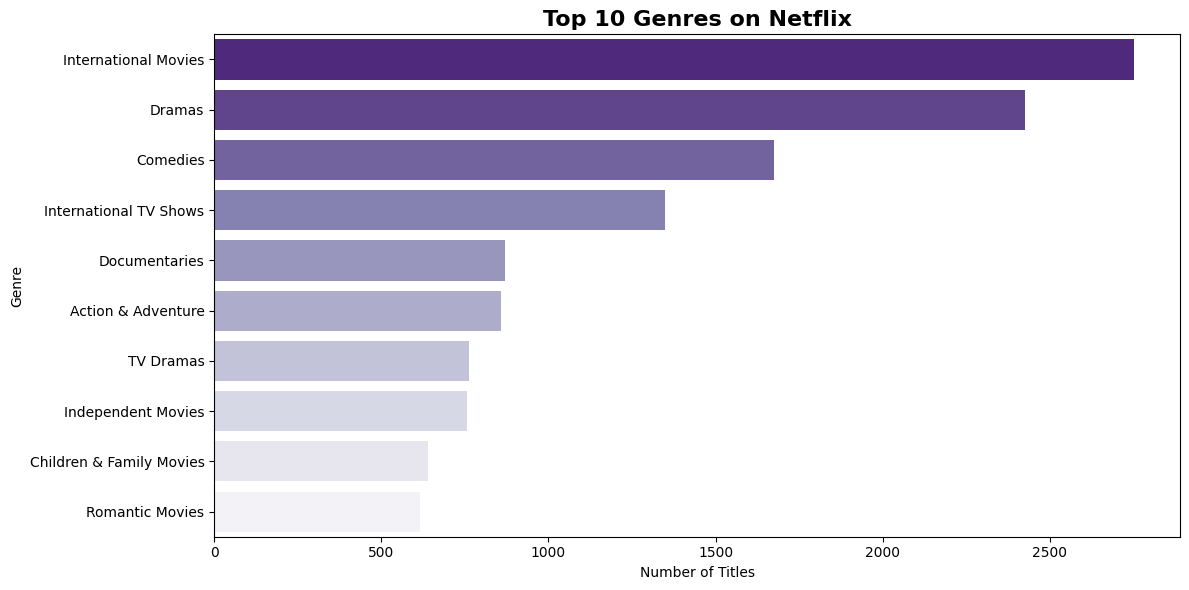

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


In [7]:
# ---- ANALYSIS 4: Top 10 Genres ----
genres = df_clean['listed_in'].str.split(',').explode().str.strip()
genre_counts = genres.value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=genre_counts.values, y=genre_counts.index, palette='Purples_r')
plt.title('Top 10 Genres on Netflix', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.tight_layout()
plt.savefig('chart4_top_genres.png', dpi=150)
plt.show()
print(genre_counts)

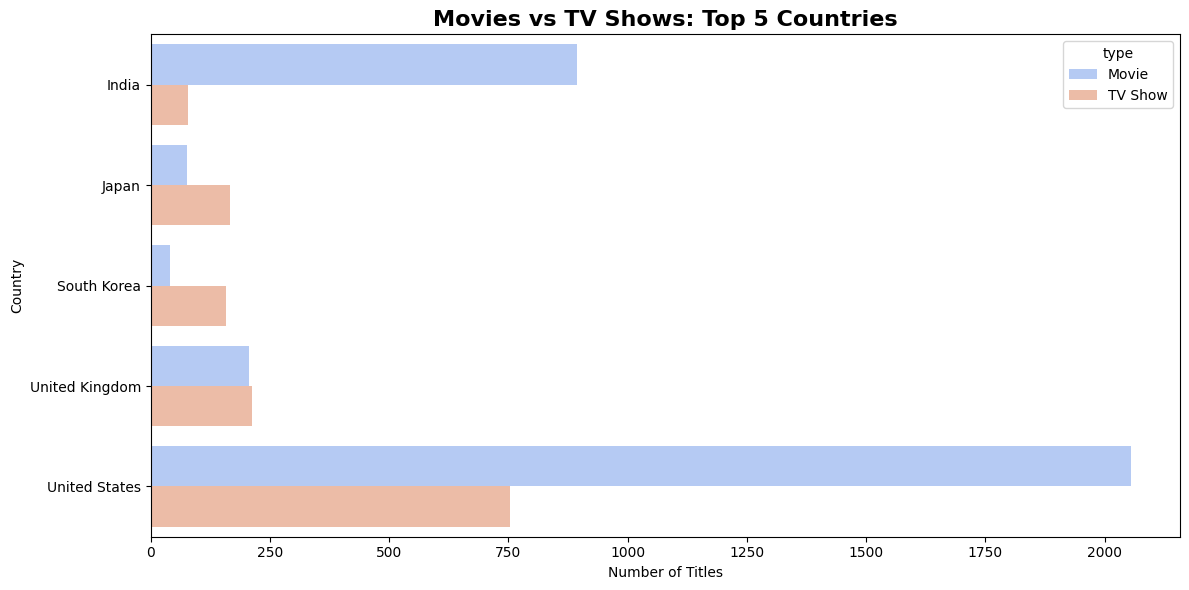

          country     type  Total_Titles
0           India    Movie           893
1           India  TV Show            79
2           Japan  TV Show           167
3           Japan    Movie            76
4     South Korea  TV Show           158
5     South Korea    Movie            41
6  United Kingdom  TV Show           212
7  United Kingdom    Movie           206
8   United States    Movie          2055
9   United States  TV Show           754


In [8]:
# ---- PYTHON APPROACH ----
top5_countries = df_clean[df_clean['country'] != 'Unknown'].groupby('country')['show_id'].count().sort_values(ascending=False).head(5).index

df_top5 = df_clean[df_clean['country'].isin(top5_countries)]
content_mix = df_top5.groupby(['country', 'type'])['show_id'].count().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(data=content_mix, x='show_id', y='country', hue='type', palette='coolwarm')
plt.title('Movies vs TV Shows: Top 5 Countries', fontsize=16, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('chart5_content_mix.png', dpi=150)
plt.show()

# ---- SQL APPROACH ----
query = """
SELECT country, type,
       COUNT(*) AS Total_Titles
FROM df_clean
WHERE country != 'Unknown'
AND country IN ('United States', 'India', 'United Kingdom', 'Japan', 'South Korea')
GROUP BY country, type
ORDER BY country, Total_Titles DESC
"""
result = sqldf(query, locals())
print(result)